# Cantilever Beam: Mode Shapes, Natural Frequencies, and FRF Grid

This notebook computes the mode shapes and natural frequencies of an Euler-Bernoulli cantilever beam, then builds a 3x3 grid of point receptance (displacement/force) transfer functions (FRFs) among three locations:

- a1 = 0.1 L
- a2 = 0.6 L
- a3 = 1.0 L (free tip)

The transfer function matrix H(ω) has entries H_ij(ω) = displacement at location i due to a unit harmonic point force at location j, computed using a modal summation with light viscous damping.

Steps:
1. Define beam + analysis parameters.
2. Compute eigenvalues β_n solving cosh(βL) cos(βL) = -1.
3. Build mass-normalized mode shapes φ_n(x).
4. Compute natural frequencies ω_n.
5. Assemble FRFs between the three points using first N modes.
6. Plot FRF magnitudes in a 3×3 subplot grid.

You can adjust number of modes, damping ratios, and frequency resolution in the parameters cell below.

In [21]:
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
from dataclasses import dataclass

# --- Beam & analysis parameters ---
@dataclass
class Beam:
    L: float      # length (m)
    E: float      # Young's modulus (Pa)
    I: float      # second moment of area (m^4)
    rho: float    # density (kg/m^3)
    A: float      # cross-sectional area (m^2)

b = 0.05           # width 0.05 m
d = 0.005          # depth 0.005 m

beam = Beam(
    L=0.4,            # length 0.4 m
    E=210e9,          # Pa
    I=b*d**3/12,      # m^4
    rho=7800.0,       # kg/m^3
    A=b*d             # m^2
)

# Modal / FRF settings
N_MODES = 3          # number of modes to include in FRF
ZETA = 0.005         # (uniform) modal damping ratio
N_X_PLOT = 400       # resolution for mode shape plots

# Locations of interest (fraction of L)
loc_fracs = np.array([0.2, 0.78, 1.0])

# Frequency sweep (auto-extended after modes computed)
FREQ_POINTS = 4000   # resolution of frequency vector

print("Parameters initialized.")

Parameters initialized.


In [22]:
# Solve for the first N_MODES roots of cosh(beta L) cos(beta L) + 1 = 0 for a cantilever
# Roots are found near ( (2n-1)pi/2 ) / L for n >=1

L = beam.L

beta_roots = []

def f_beta(b):
    return np.cosh(b*L)*np.cos(b*L) + 1.0

# Bracket and find roots using known approximate spacing
n = 1
while len(beta_roots) < N_MODES:
    # initial guess region around (2n-1)pi/(2L)
    guess = (2*n - 1) * np.pi / (2*L)
    # Use a small search window to find sign change
    a = guess * 0.9
    b = guess * 1.1
    # Expand window until sign change (avoid infinite loop with cap)
    for _ in range(50):
        fa = f_beta(a)
        fb = f_beta(b)
        if fa * fb < 0:
            root = opt.brentq(f_beta, a, b)
            beta_roots.append(root)
            break
        else:
            a *= 0.95
            b *= 1.05
    n += 1

beta_roots = np.array(beta_roots)

# Natural frequencies: omega_n = beta_n^2 * sqrt(EI/(rho A))
EI = beam.E * beam.I
mu = beam.rho * beam.A   # mass per unit length
omega_n = beta_roots**2 * np.sqrt(EI / mu)
freq_n = omega_n / (2*np.pi)

for i,(b,f) in enumerate(zip(beta_roots, freq_n), start=1):
    print(f"Mode {i}: beta={b:.5f}  f_n={f:.2f} Hz")

Mode 1: beta=4.68776  f_n=26.19 Hz
Mode 2: beta=11.73523  f_n=164.15 Hz
Mode 3: beta=19.63689  f_n=459.63 Hz


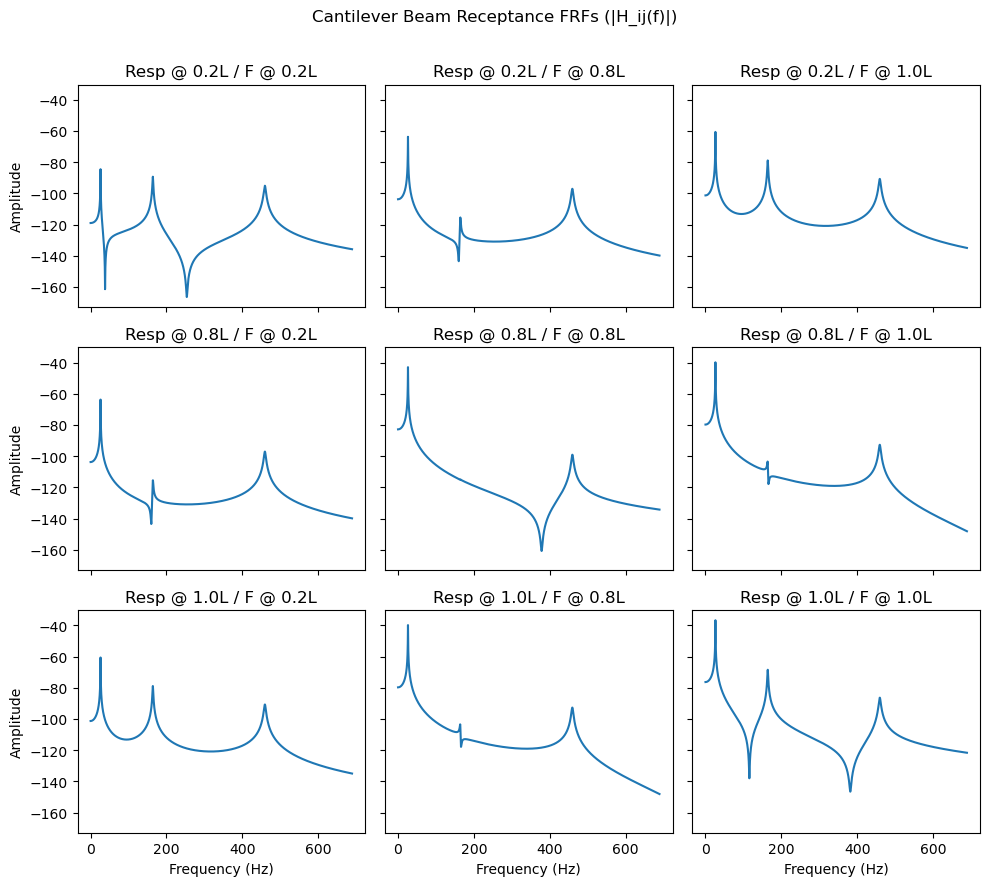

In [23]:
# Assemble receptance FRFs between selected points using modal summation:
# H_ij(ω) = Σ ( φ_n(x_i) φ_n(x_j) / ( -ω^2 + 2j ζ_n ω_n ω + ω_n^2 ) )
# Using unit modal mass since modes are mass-normalized.

def mode_shape(beta, x):
    # Cantilever beam mode shape (mass-normalized, ignoring sign)
    L = beam.L
    phi = (
        np.cosh(beta * x)
        - np.cos(beta * x)
        - (
            (np.cosh(beta * L) + np.cos(beta * L))
            / (np.sinh(beta * L) + np.sin(beta * L))
        )
        * (np.sinh(beta * x) - np.sin(beta * x))
    )
    return phi

x_points = loc_fracs * L
phi_at_points = np.array([[mode_shape(b, x) for b in beta_roots[:N_MODES]] for x in x_points])

# Frequency vector up to e.g. 1.5 * highest computed natural frequency
f_max = 1.5 * freq_n[min(N_MODES, len(freq_n))-1]
f = np.linspace(0.01, f_max, FREQ_POINTS)
omega = 2*np.pi * f

zeta = np.full(N_MODES, ZETA)

# Denominator matrix for each mode: (ω_n^2 - ω^2 + 2j ζ ω_n ω)
H = np.zeros((len(x_points), len(x_points), len(f)), dtype=complex)

for m in range(N_MODES):
    wn = omega_n[m]
    num_vec = phi_at_points[:, m]
    den = (wn**2 - omega**2) + 1j*(2*zeta[m]*wn*omega)
    outer = np.outer(num_vec, num_vec)
    H += outer[:,:,None] / den[None,None,:]

# Plot 3x3 grid of magnitude FRFs
fig, axes = plt.subplots(3,3, figsize=(10,9), sharex=True, sharey=True)
for i in range(3):
    for j in range(3):
        ax = axes[i,j]
        mag = np.abs(H[i,j,:])
        ax.plot(f, 20*np.log10(mag))
        if i==2:
            ax.set_xlabel('Frequency (Hz)')
        if j==0:
            ax.set_ylabel('Amplitude')
        ax.set_title(f'Resp @ {loc_fracs[i]:.1f}L / F @ {loc_fracs[j]:.1f}L')

plt.suptitle('Cantilever Beam Receptance FRFs (|H_ij(f)|)')
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

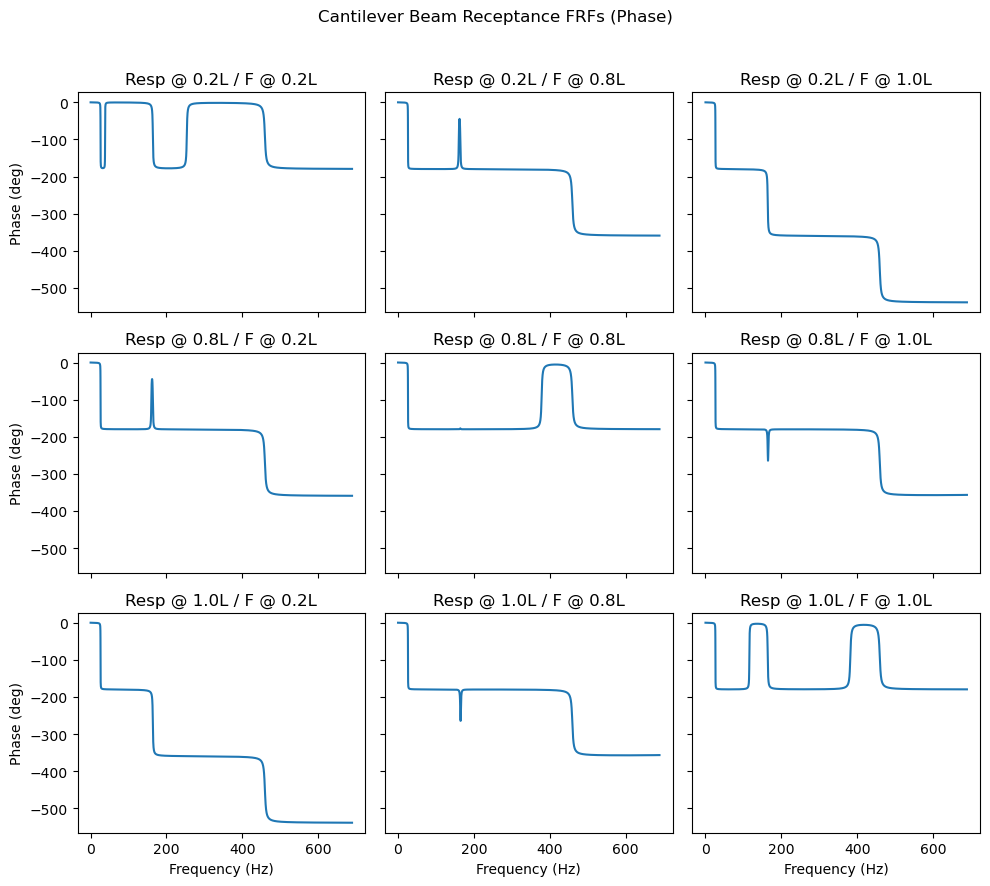

In [24]:
# Phase (degrees) FRF grid
fig_phase, axes_phase = plt.subplots(3, 3, figsize=(10, 9), sharex=True, sharey=True)

for ii in range(3):
    for jj in range(3):
        axp = axes_phase[ii, jj]
        phase_deg = np.unwrap(np.angle(H[ii, jj, :])) * 180 / np.pi
        axp.plot(f, phase_deg)
        if ii == 2:
            axp.set_xlabel('Frequency (Hz)')
        if jj == 0:
            axp.set_ylabel('Phase (deg)')
        axp.set_title(f'Resp @ {loc_fracs[ii]:.1f}L / F @ {loc_fracs[jj]:.1f}L')

plt.suptitle('Cantilever Beam Receptance FRFs (Phase)')
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

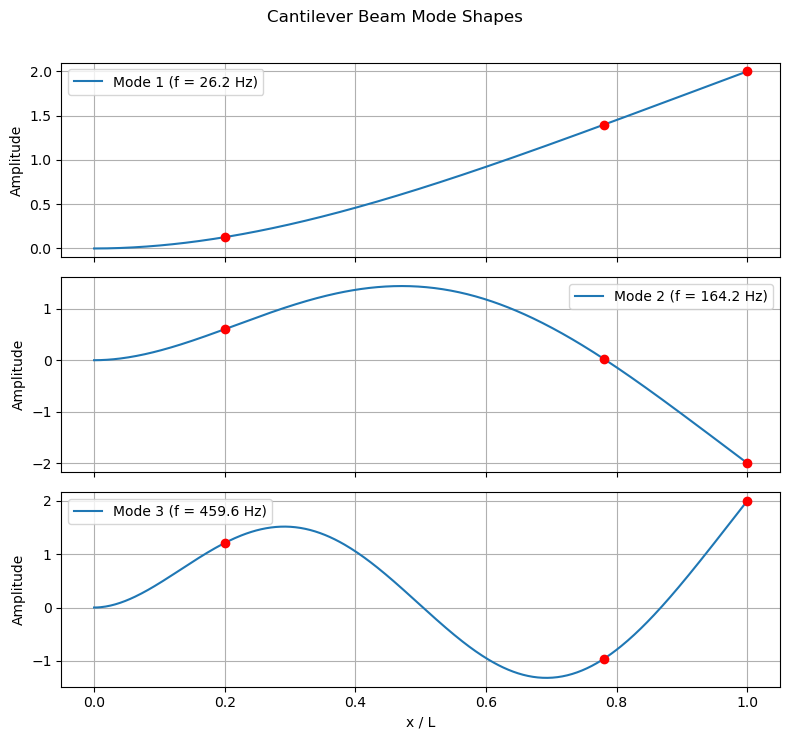

In [25]:
# Plot mode shapes for the first N_MODES
x_plot = np.linspace(0, L, N_X_PLOT)
fig_modes, axes_modes = plt.subplots(N_MODES, 1, figsize=(8, 2.5*N_MODES), sharex=True)

for idx in range(N_MODES):
    phi_plot = mode_shape(beta_roots[idx], x_plot)
    axm = axes_modes[idx]
    axm.plot(x_plot / L, phi_plot, label=f'Mode {idx+1} (f = {freq_n[idx]:.1f} Hz)')
    axm.scatter(loc_fracs, mode_shape(beta_roots[idx], loc_fracs * L), color='red', zorder=5)
    axm.set_ylabel('Amplitude')
    axm.legend()
    axm.grid(True)
axes_modes[-1].set_xlabel('x / L')
plt.suptitle('Cantilever Beam Mode Shapes')
plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

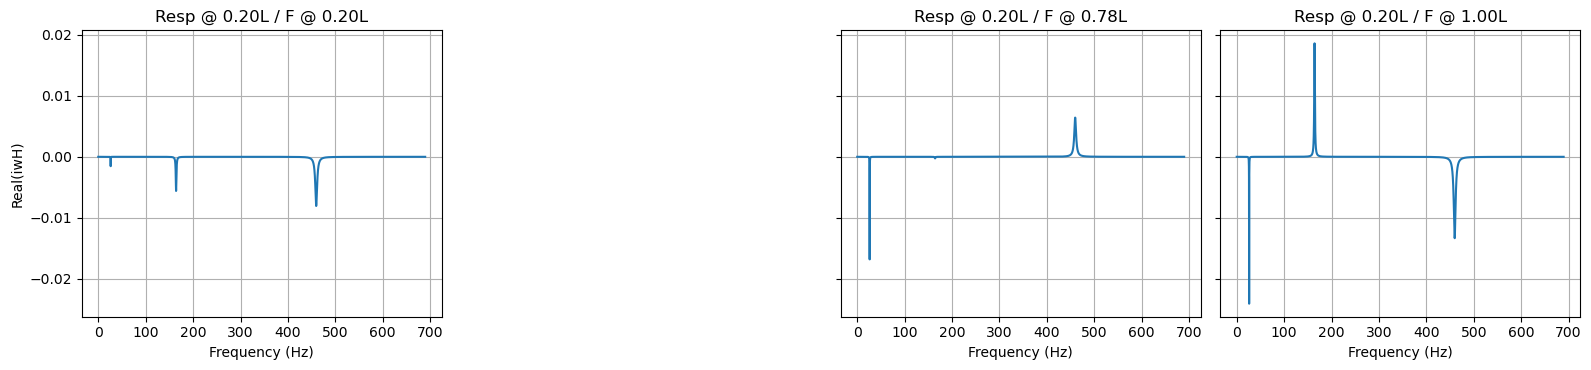

In [36]:
# Real part of FRFs (response at 0.20L) shown in a row of three subplots
fig_imag_top, axes_imag_top = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

resp_idx = 0  # response at 0.20L

# Leave second subplot blank
axes_imag_top[1].axis('off')

plot_positions = [0, 2, 3]  # where to place the three FRFs
for ax_pos, (j, frac) in zip(plot_positions, enumerate(loc_fracs)):
    ax = axes_imag_top[ax_pos]
    ax.plot(f, f * H[resp_idx, j, :].imag)
    ax.set_xlabel('Frequency (Hz)')
    if ax_pos == 0:
        ax.set_ylabel('Real(iwH)')
    ax.set_title(f'Resp @ {loc_fracs[resp_idx]:.2f}L / F @ {frac:.2f}L')
    ax.grid(True)

# fig_imag_top.suptitle('Imaginary Part - Top Row FRFs (Response @ 0.20L)')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Notes / Adjustments
- Increase `N_MODES` for higher-frequency accuracy.
- Change `ZETA` for different damping.
- Adjust cross-sectional properties (`A`, `I`) as needed.
- The FRFs are receptances (displacement per unit force). Multiply by force spectrum to get responses.
- To export FRF matrix at a specific frequency index k: `H[:,:,k]`.